True parameters:
beta0 = 2.0, beta1 = 0.5

Least Squares estimate:
[2.06444309 0.4420166 ]

Maximum Likelihood estimate:
[2.06444309 0.4420166 ]

MAP estimate:
[1.92064949 0.46309272]


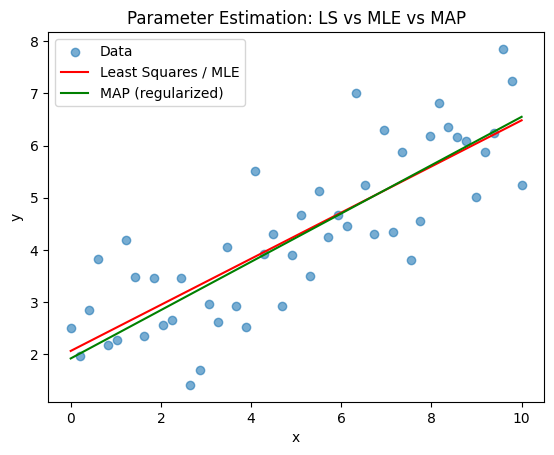

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate synthetic data
# -----------------------------
np.random.seed(42)

n = 50
x = np.linspace(0, 10, n)
true_beta0 = 2.0
true_beta1 = 0.5
sigma = 1.0  # noise std

noise = np.random.normal(0, sigma, size=n)
y = true_beta0 + true_beta1 * x + noise

# Design matrix (add intercept)
X = np.column_stack((np.ones(n), x))

# -----------------------------
# 2. Least Squares Estimation
# -----------------------------
# beta_hat = (X^T X)^(-1) X^T y
beta_ls = np.linalg.inv(X.T @ X) @ X.T @ y

# -----------------------------
# 3. Maximum Likelihood Estimation
# -----------------------------
# For Gaussian noise, MLE == Least Squares
beta_mle = beta_ls.copy()

# -----------------------------
# 4. Maximum A Posteriori (MAP)
# -----------------------------
# Assume prior: beta ~ N(0, tau^2 I)
tau = 1.0  # prior std

# MAP solution:
# beta_map = (X^T X + (sigma^2 / tau^2) I)^(-1) X^T y
lambda_reg = sigma**2 / tau**2
I = np.eye(X.shape[1])

beta_map = np.linalg.inv(X.T @ X + lambda_reg * I) @ X.T @ y

# -----------------------------
# 5. Print results
# -----------------------------
print("True parameters:")
print(f"beta0 = {true_beta0}, beta1 = {true_beta1}\n")

print("Least Squares estimate:")
print(beta_ls)

print("\nMaximum Likelihood estimate:")
print(beta_mle)

print("\nMAP estimate:")
print(beta_map)

# -----------------------------
# 6. Plot results
# -----------------------------
x_plot = np.linspace(0, 10, 100)
X_plot = np.column_stack((np.ones(100), x_plot))

y_ls = X_plot @ beta_ls
y_map = X_plot @ beta_map

plt.scatter(x, y, label="Data", alpha=0.6)
plt.plot(x_plot, y_ls, label="Least Squares / MLE", color="red")
plt.plot(x_plot, y_map, label="MAP (regularized)", color="green")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parameter Estimation: LS vs MLE vs MAP")
plt.show()